In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from idun_guardian_sdk import GuardianClient, FileTypes
import scipy.signal

In [2]:
# Download an EEG file recording

my_api_token = "idun_MWSQ4pkewAGNz8wwYzw_NsweXihLC8tIcFzah8vqqys4Nc-ALzjfTwl2"
my_recording_id = "1770732156922" # neue concentraded datei


client = GuardianClient(api_token=my_api_token)
client.download_file(recording_id=my_recording_id, file_type=FileTypes.EEG)

[INFO] 2026-02-10 15:25:11,735: [API]: File saved: 'eeg_1770732156922.csv'


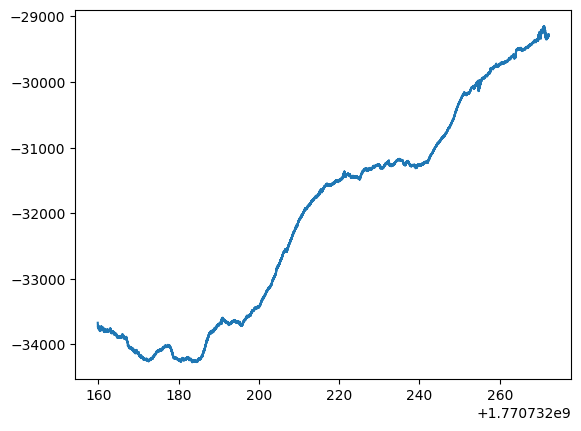

In [3]:
# Daten einlesen & Plotten

x = pd.read_csv("../data/eeg_1770732156922.csv")

plt.figure()
plt.plot(x["timestamp"], x["ch1"])
plt.show()

In [4]:
sos_hp = scipy.signal.iirdesign(wp=1, ws=0.5, gpass=1, gstop=40, analog=False, ftype='butter', output='sos', fs=250)
x_filt = scipy.signal.sosfilt(sos_hp, x['ch1'], zi=None)

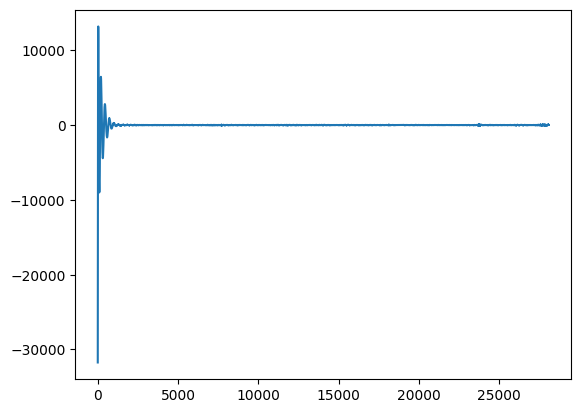

In [6]:
plt.plot(x_filt)